# PWF – Expertenmodell

## Multivariate logistische Regression mit NumPy

### Features
- Power_W
- Torque [Nm]

### Begründung
Power Failure wird physikalisch durch Leistung und Drehmoment erklärt.

In [6]:
# Import der benötigten Bibliotheken für numerische Berechnungen, Datenverarbeitung und Visualisierung
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lade den Datensatz aus der CSV-Datei
# Die Datei muss im gleichen Verzeichnis wie das Notebook liegen
df = pd.read_csv("ai4i2020.csv")

# Zeige die ersten Zeilen zur Kontrolle des geladenen Datensatzes
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Feature Engineering

In [7]:
# Feature Engineering: neue Merkmale, die für das Modell relevant sind

# Temperaturdifferenz als Maß für Wärmeabfuhr und Belastung
df["Temp_diff"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

# Mechanische Leistung in Watt aus Drehmoment und Drehzahl
df["Power_W"] = (
    df["Torque [Nm]"]
    * (2*np.pi*df["Rotational speed [rpm]"]/60)
)

# Overstrain-Index als Produkt aus Drehmoment und Werkzeugverschleiß
df["Overstrain_index"] = (
    df["Torque [Nm]"]
    * df["Tool wear [min]"]
)

## Hilfsfunktionen

In [ ]:
def sigmoid(z):

    # Sigmoid-Funktion für die Klassifikationswahrscheinlichkeit
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def add_intercept(X):

    # Füge eine Bias-Spalte mit Einsen hinzu
    return np.c_[np.ones((X.shape[0],1)), X]


def standardize(X):

    # Standardisiere Merkmale auf Mittelwert 0 und Standardabweichung 1
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean)/std


def weighted_log_loss(y, p, weights):

    # Gewichtete logistische Verlustfunktion zum Ausgleich unbalancierter Klassen
    eps = 1e-15
    p = np.clip(p, eps, 1-eps)
    return -np.mean(
        weights * (
            y*np.log(p)
            +
            (1-y)*np.log(1-p)
        )
    )


def fit_logistic_regression(
    X,
    y,
    learning_rate=0.05,
    epochs=3000 #ein kompletter Durchlauf durch den gesamten Datensatz
):

    # Trainiere das Modell mit Gradientenabstieg
    Xb = add_intercept(X)
    m, n = Xb.shape
    theta = np.zeros(n)

    # Bestimme Klassenhäufigkeiten und Gewichte
    positives = np.sum(y == 1)
    negatives = np.sum(y == 0)
    weight_pos = m / (2*positives)
    weight_neg = m / (2*negatives)
    weights = np.where(
        y == 1,
        weight_pos,
        weight_neg
    )

    history = []

    for epoch in range(epochs):
        p = sigmoid(Xb @ theta)
        error = p - y
        gradient = (
            Xb.T @ (weights * error)
        ) / m
        theta -= learning_rate * gradient

        # Speichere Verlauf der Verlustfunktion in regelmäßigen Abständen
        if epoch % 500 == 0:
            loss = weighted_log_loss(
                y,
                p,
                weights
            )
            history.append(loss)

    return theta, history


def predict(X, theta):

    # Erzeuge Klassenvorhersagen aus den Wahrscheinlichkeiten
    Xb = add_intercept(X)
    p = sigmoid(Xb @ theta)
    return (p >= 0.5).astype(int)


def confusion_matrix_manual(y_true, y_pred):

    # Berechne TP, TN, FP, FN manuell
    tn = np.sum(
        (y_true == 0)
        &
        (y_pred == 0)
    )
    fp = np.sum(
        (y_true == 0)
        &
        (y_pred == 1)
    )
    fn = np.sum(
        (y_true == 1)
        &
        (y_pred == 0)
    )
    tp = np.sum(
        (y_true == 1)
        &
        (y_pred == 1)
    )
    return np.array([
        [tn, fp],
        [fn, tp]
    ])


def f1_score_manual(y_true, y_pred):

    # Berechne den F1-Score aus der Konfusionsmatrix
    cm = confusion_matrix_manual(
        y_true,
        y_pred
    )
    tn, fp = cm[0]
    fn, tp = cm[1]
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return (
        2 * precision * recall
        /
        (precision + recall)
    )


## PWF-Modell trainieren

In [9]:
# Wähle die Merkmale für das PWF-Modell aus
features = ['Power_W', 'Torque [Nm]']

# Erzeuge Eingangsmerkmale und Zielvariable
X = df[features].values
y = df["PWF"].values

# Standardisiere die Merkmale vor dem Training
X = standardize(X)

# Trainiere das logistische Regressionsmodell
theta, history = fit_logistic_regression(
    X,
    y
)

# Vorhersage auf denselben Daten
y_pred = predict(X, theta)

# Berechne die Konfusionsmatrix und den F1-Score
cm = confusion_matrix_manual(
    y,
    y_pred
)

f1 = f1_score_manual(
    y,
    y_pred
)

# Ergebnisse ausgeben
print("Theta:", theta)
print("\nConfusion Matrix:")

print(cm)
print("\nF1-Score:", round(f1,4))

Theta: [-0.09172144  0.08713851  0.118417  ]

Confusion Matrix:
[[6691 3214]
 [  31   64]]

F1-Score: 0.0379


## Trennlinie plotten

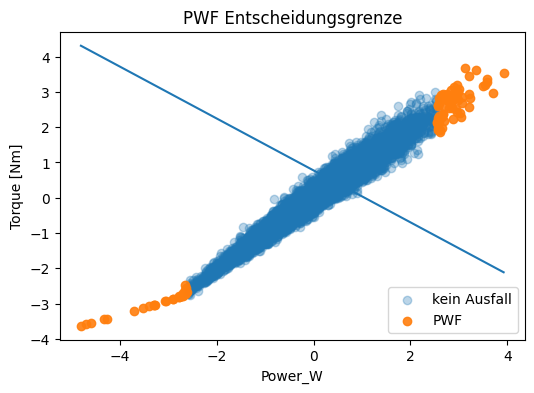

In [10]:
# Zeichne die Datenpunkte und die Entscheidungsgrenze
plt.figure(figsize=(6,4))

plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    alpha=0.3,
    label="kein Ausfall"
)

plt.scatter(
    X[y==1][:,0],#alle Zeilen :
#aber nur Spalte x-spalte
    X[y==1][:,1],
    alpha=0.9,
    label="PWF"
)

# Erzeuge Werte für die x-Achse der Entscheidungsgrenze
x_values = np.linspace(#200 gleichmäßig verteilte Zahlen zwischen:min und max
    X[:,0].min(),
    X[:,0].max(),
    200
)

# Berechne die lineare Trennlinie aus den gelernten Modellparametern
y_values = (
    -(theta[0]
    + theta[1]*x_values)
    / theta[2]
)

plt.plot(
    x_values,
    y_values
)

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("PWF Entscheidungsgrenze")
plt.legend()
plt.show()


# Interpretation

## Features
- Power_W
- Torque [Nm]

## Physikalische Begründung
Power Failure wird physikalisch durch Leistung und Drehmoment erklärt.

## Bewertung
- Die gewichtete Kostenfunktion verbessert die Behandlung der Minderheitsklasse.
- Der F1-Score ist besser geeignet als Accuracy.
- Die Trennlinie zeigt die Entscheidungsgrenze der logistischen Regression.
